# Using Optimizers

An optimizer is the search engine of a program. On each step it asks the generators to propose
candidate sequences, scores those candidates with the constraints, and keeps the ones that score
best; over many steps the retained sequences move toward the design objective. A `Program` runs
one or more optimizers and collects the final results.

This guide describes the optimizer interface, the built-in optimizers and what each is suited
to, how to run one, and how to chain several into a multi-stage program. Custom optimizers are
out of scope; the built-in set covers the common search strategies.

## The loop

Every optimizer is constructed the same way: it is given the `constructs` it designs, the
`generators` that propose sequences, the `constraints` that score them, and a `config` that sets
the search parameters. The optimizer then repeats a propose-score-select loop.

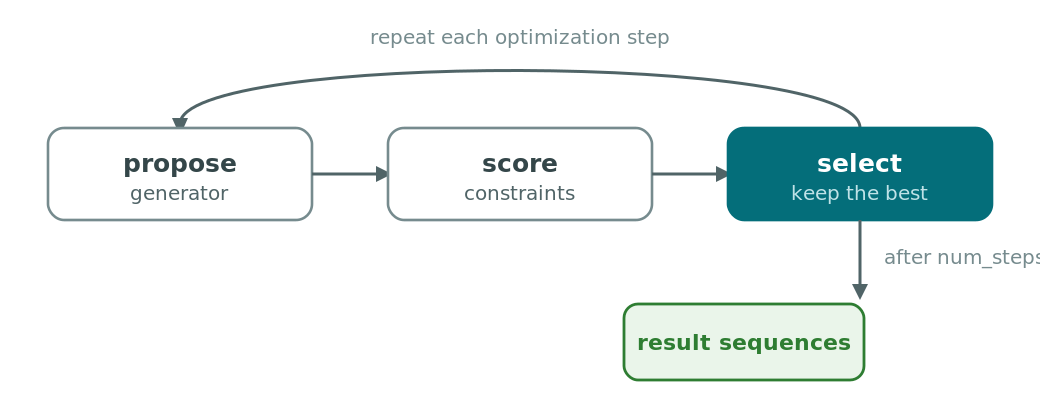

The generators and constraints are the same objects described in
[Using Generators](/language/guides/using-generators) and
[Using Constraints](/language/guides/using-constraints); the optimizer coordinates them. What
differs between optimizers is the strategy by which proposals are generated and selected, and
the parameters that govern it.

## The built-in optimizers

<CardGroup cols={2}>
  <Card title="MCMC" icon="activity" href="/language/optimizers/mcmc">
    Metropolis-Hastings sampling: each proposal is accepted or rejected against a temperature
    schedule. A general-purpose local search.
  </Card>
  <Card title="Rejection Sampling" icon="filter" href="/language/optimizers/rejection-sampling">
    Draw a batch of candidates and keep those below an energy threshold. Useful for filtering
    and for a first enrichment stage.
  </Card>
  <Card title="Beam Search" icon="git-branch" href="/language/optimizers/beam-search">
    Maintain a beam of partial sequences, extending and pruning them. Suited to autoregressive
    generation.
  </Card>
  <Card title="Cycling" icon="rotate-cw" href="/language/optimizers/cycling">
    Alternate between two providers, such as structure prediction and inverse folding. The
    Protein Hunter pattern.
  </Card>
  <Card title="Gradient" icon="trending-down" href="/language/optimizers/gradient">
    Differentiable optimization of position weights by gradient descent, following a
    soft-to-hard schedule.
  </Card>
</CardGroup>

## Running an optimizer

The example below balances the composition of a 100 bp DNA insert with the `MCMCOptimizer`. The
optimizer's `config` sets the search budget: `num_steps` is the number of propose-score-select
iterations, `proposals_per_result` is how many candidates are evaluated per step, and the
temperature controls how readily worse proposals are accepted (higher is more exploratory).

In [ ]:
from proto_language.core import Segment, Construct, Constraint, Program
from proto_language.constraint import gc_content_constraint
from proto_language.generator import RandomNucleotideGenerator, RandomNucleotideGeneratorConfig
from proto_language.optimizer import MCMCOptimizer, MCMCOptimizerConfig

# A 100 bp DNA insert, a random-mutation generator, and a GC-content objective.
insert = Segment(length=100, sequence_type="dna", label="insert")
construct = Construct([insert])

generator = RandomNucleotideGenerator(RandomNucleotideGeneratorConfig())
generator.assign(insert)

gc = Constraint(
    inputs=[insert],
    function=gc_content_constraint,
    function_config={"min_gc": 40, "max_gc": 60},
    label="gc_content",
)

# The config is where the search strategy is tuned.
optimizer = MCMCOptimizer(
    constructs=[construct],
    generators=[generator],
    constraints=[gc],
    config=MCMCOptimizerConfig(
        num_results=1,
        proposals_per_result=1,
        num_steps=100,
        max_temperature=1.0,
    ),
)

# A Program runs the optimizer and collects the result.
program = Program(optimizers=[optimizer], num_results=1)
program.run()

best = program.constructs[0].joined_sequences[0]
gc_pct = best.metadata["segments"]["insert"]["constraints"]["gc_content"]["data"]["gc_content"]
print(f"final sequence: {best.sequence}")
print(f"GC content:     {gc_pct:.1f}%")

## Chaining optimizers into stages

A `Program` may run several optimizers in sequence. When the stages share the same `Segment`
and `Construct` objects, the result sequences of one stage become the starting point of the
next, so the design is refined incrementally rather than rebuilt. This is how a coarse, broad
search is followed by a fine, narrow one.

The two stages below operate on a single 20 bp insert: rejection sampling first enriches it
toward a wide 70-100% GC window, then MCMC refines it into a tight 80-90% window.

In [ ]:
from proto_tools.transforms.masking import MaskingStrategy
from proto_language.optimizer import (
    RejectionSamplingOptimizer,
    RejectionSamplingOptimizerConfig,
)

# One construct is reused across both stages, so state carries over between them.
insert = Segment(length=20, sequence_type="dna", label="insert")
construct = Construct([insert])

# Stage 1: rejection sampling makes large moves to enrich GC content broadly.
gen1 = RandomNucleotideGenerator(
    RandomNucleotideGeneratorConfig(masking_strategy=MaskingStrategy(num_mutations=10))
)
gen1.assign(insert)
stage1 = RejectionSamplingOptimizer(
    constructs=[construct],
    generators=[gen1],
    constraints=[Constraint(inputs=[insert], function=gc_content_constraint,
                            function_config={"min_gc": 70, "max_gc": 100}, label="gc_enrich")],
    config=RejectionSamplingOptimizerConfig(num_samples=10, num_results=3),
)

# Stage 2: MCMC makes small moves to refine into a tighter window.
gen2 = RandomNucleotideGenerator(
    RandomNucleotideGeneratorConfig(masking_strategy=MaskingStrategy(num_mutations=1))
)
gen2.assign(insert)
stage2 = MCMCOptimizer(
    constructs=[construct],
    generators=[gen2],
    constraints=[Constraint(inputs=[insert], function=gc_content_constraint,
                            function_config={"min_gc": 80, "max_gc": 90}, label="gc_refine")],
    config=MCMCOptimizerConfig(num_results=1, proposals_per_result=20, num_steps=10, max_temperature=2.0),
)

# The program runs the stages in order on the shared construct.
program = Program(optimizers=[stage1, stage2], num_results=1)
program.run()

best = program.constructs[0].joined_sequences[0]
gc_pct = best.metadata["segments"]["insert"]["constraints"]["gc_refine"]["data"]["gc_content"]
print(f"final sequence: {best.sequence}")
print(f"GC content:     {gc_pct:.1f}%")

## The model-backed optimizers

Two optimizers coordinate machine-learning tools rather than composition constraints, and so
require a GPU. The `CyclingOptimizer` alternates between two providers; in the Protein Hunter
program it cycles between structure prediction and inverse folding, each round refining the
sequence toward a target fold. The `GradientOptimizer` pairs with `PositionWeightGenerator` to
optimize a differentiable sequence by gradient descent, following a soft-to-hard schedule that
sharpens a continuous sequence into a discrete one. Complete, runnable versions of both appear
in the Example Programs.

## Practical considerations

<Tip>
The search budget lives in the optimizer `config`: `num_steps` (or `num_samples`) sets how long
the search runs, `num_results` sets how many designs are returned, and `proposals_per_result`
sets how many candidates are evaluated per step. Start small while iterating, then scale up.
</Tip>

<Note>
Multi-stage programs share state through object identity: the later optimizers must be given the
same `Segment` and `Construct` instances as the earlier ones for the design to carry over.
Constructing fresh segments for a later stage starts it from scratch instead.
</Note>

<Tip>
Pass `verbose=True` in a config, or a `custom_logging` callable to the optimizer, to inspect the
score of the best sequence at each step while tuning a search.
</Tip>

## Next Steps

<CardGroup cols={2}>
  <Card title="Using Constraints" icon="ruler" href="/language/guides/using-constraints">
    Define the objective the optimizer minimizes.
  </Card>
  <Card title="Using Generators" icon="shuffle" href="/language/guides/using-generators">
    Choose the moves the optimizer proposes.
  </Card>
  <Card title="Optimizers concept" icon="book" href="/language/concepts/optimizers">
    How optimizers relate to the rest of the model.
  </Card>
  <Card title="Optimizer reference" icon="list" href="/language/optimizers/mcmc">
    The full catalog of built-in optimizers.
  </Card>
</CardGroup>